In [ ]:
import torch
from utils.utils import prepare_truths_df
from metrics.loss import kaggle_compute_metrics
from configs.cfg import cfg
import pandas as pd
import numpy as np

def calc_beta(beta) -> float:
    
    weights = {
        'apo-ferritin': 1, #1
        'beta-amylase': 0, #0
        'beta-galactosidase': 2, #2
        'ribosome': 1, #1
        'thyroglobulin': 2, #2
        'virus-like-particle': 1, #1
    }
    
    results = {}
    for particle_type in weights.keys():
        results[particle_type] = {
            'total_tp': 0,
            'total_fp': 0,
            'total_fn': 0,
        }
       
# apo-ferritin: TP=40, FP=23, FN=6
# beta-galactosidase: TP=10, FP=72, FN=2
# ribosome: TP=29, FP=49, FN=2
# thyroglobulin: TP=27, FP=118, FN=3
# virus-like-particle: TP=11, FP=5, FN=0    
            
    results['apo-ferritin']['total_tp'] = 40
    results['apo-ferritin']['total_fp'] = 23
    results['apo-ferritin']['total_fn'] = 6
    
    results['beta-galactosidase']['total_tp'] = 10
    results['beta-galactosidase']['total_fp'] = 45
    results['beta-galactosidase']['total_fn'] = 4
    
    results['ribosome']['total_tp'] = 29
    results['ribosome']['total_fp'] =49
    results['ribosome']['total_fn'] = 2
    
    results['thyroglobulin']['total_tp'] = 27
    results['thyroglobulin']['total_fp'] = 50
    results['thyroglobulin']['total_fn'] = 4
    
    results['virus-like-particle']['total_tp'] = 11
    results['virus-like-particle']['total_fp'] = 5
    results['virus-like-particle']['total_fn'] = 0
    aggregate_fbeta = 0.0
    for particle_type, totals in results.items():
        tp = totals['total_tp']
        fp = totals['total_fp']
        fn = totals['total_fn'] 
        
        print(f'{particle_type}: TP={tp}, FP={fp}, FN={fn}')

        precision = tp / (tp + fp) if tp + fp > 0 else 0
        recall = tp / (tp + fn) if tp + fn > 0 else 0
        fbeta = (1 + 4**2) * (precision * recall) / (4**2 * precision + recall) if (precision + recall) > 0 else 0.0
        aggregate_fbeta += fbeta * weights.get(particle_type, 1.0)

    if weights:
        aggregate_fbeta = aggregate_fbeta / sum(weights.values())
    else:
        aggregate_fbeta = aggregate_fbeta / len(results)
    return aggregate_fbeta

submission = pd.read_csv('logs/submission.csv')

beta_score = calc_beta(4)
print(f'Beta Score: {beta_score}')

In [ ]:
(0.8872381658915502 + 0.8018867924528302) / 2

In [ ]:
import zarr
import matplotlib.pyplot as plt
from utils.utils import  z_score_normalize, load_labels

level = 0
def load_tomogram(tomogram, type='denoised'):    
    zarr_file = zarr.open(f'/home/daniel/AI/Projects/3.CryoET/1.CompetitionModel/datamount/train/static/{tomogram}/VoxelSpacing10.000/{type}.zarr', mode='r')
    return zarr_file[level]

label = load_labels('TS_5_4').astype('uint8')
print(label.shape)

def normalize(x):
    lower, upper = np.percentile(x, (0.5, 99.5))
    x = np.clip(x, lower, upper)
    x = (x - x.min()) / (x.max() - x.min() + 1e-12) * 255
    return x.round().astype("uint8")

def z_score_normalize_clip(x):
    lower, upper = np.percentile(x, (0.5, 99.5))
    x = np.clip(x, lower, upper)
    mean = np.mean(x)
    std = np.std(x)
    return (x - mean) / std

def normalise_by_percentile(data, min=5, max=99):
    min = np.percentile(data,min)
    max = np.percentile(data,max)
    data = (data-min)/(max-min)
    return data

tomogram = load_tomogram('TS_5_4')
tomogram = normalize(tomogram)
shape = tomogram.shape
print(tomogram.max(), tomogram.min())
# padded_shape = [i + 2 * cfg.pad_size for i in shape]

# temp = np.zeros(padded_shape)
# temp[cfg.pad_size:padded_shape[0] - cfg.pad_size,
#     cfg.pad_size:padded_shape[1] - cfg.pad_size,
#     cfg.pad_size:padded_shape[2] - cfg.pad_size] = tomogram
# tomogram = temp
# factor = level + 1
# dlta = 36
# z = 101
# y = 617
# x = 343
# z, y, x = z//factor, y//factor, x//factor
# ### 20, 162, 280
# plt.figure(figsize=(3, 3))
# plt.imshow(label[z, y-dlta:y+dlta, x-dlta:x+dlta], cmap='gray')
# plt.show()


# FIXED POST PROCESSING

In [10]:
def np_find_connected_componet(probability, threshold):
    num_particle_type, D, H, W = probability.shape
    binary = probability > np.array(threshold).reshape(num_particle_type,1,1,1)
    componet = np.zeros((num_particle_type, D, H, W), np.uint32)
    for i in range(num_particle_type):
        componet[i] = cc3d.connected_components(binary[i])
    return componet

def np_find_centroid(componet):
    centroid =[]
    num_particle_type, D, H, W = componet.shape
    for i in range(num_particle_type):
        stats = cc3d.statistics(componet[i])
        zyx=stats['centroids'][1:]
        xyz = np.ascontiguousarray(zyx[:,::-1])
        centroid.append(xyz)
    return centroid

In [ ]:
import numpy as np
import torch
import torch.nn.functional as F

def load_labels(tomogram):
    label = np.load(f'/home/daniel/AI/Projects/3.CryoET/1.CompetitionModel/datamount/train/truths/{tomogram}.npy')
    return label

label = load_labels('TS_5_4').astype('uint8')
label = torch.tensor(label).squeeze(0).to('cuda')
label = torch.nn.functional.one_hot(label.long(), num_classes=6).permute(3,0,1,2).float()
components, confidences = find_connected_component_with_confidence(label[1:], max_radius=30)
print(components.max())
print(confidences)

# centroids = find_centroid(components, tomogram='TS_5_4')
# print(len(centroids))

In [ ]:
import numpy as np
import cv2
from numpy.fft import fft2, ifft2
from scipy.signal import gaussian

def transform(image):
    i_min = image.min()
    i_max = image.max()

    image = ((image - i_min)/(i_max - i_min)) * 255
    return image.astype(np.uint8)

#GaussianBlur
def standard_scaler(image): 
    kernel_size = 9
    image = cv2.GaussianBlur(image, (kernel_size, kernel_size), 0)
    mu = np.mean(image)
    sigma = np.std(image)
    image = (image - mu)/sigma
    image = transform(image).astype(np.uint8)
    return image

#fastNlMeansDenoising
def contrast_enhancement(image):
    enhanced_image = cv2.fastNlMeansDenoising(image, None, h=10, templateWindowSize=3, searchWindowSize=7)
    
    return enhanced_image


def gaussian_kernel(kernel_size = 3):
    h = gaussian(kernel_size, kernel_size / 3).reshape(kernel_size, 1)
    h = np.dot(h, h.transpose())
    h /= np.sum(h)
    return h

#wiener_filter
def wiener_filter(img, kernel, K):
    kernel /= np.sum(kernel)
    dummy = np.copy(img)
    dummy = fft2(dummy)
    kernel = fft2(kernel, s = img.shape)
    kernel = np.conj(kernel) / (np.abs(kernel) ** 2 + K)
    dummy = dummy * kernel
    dummy = np.abs(ifft2(dummy))
    return dummy

def clahe(image):
    clahe = cv2.createCLAHE(clipLimit=1.0, tileGridSize=(16,16))

    # Apply CLAHE to the image
    img_equalized = clahe.apply(transform(image))
    return img_equalized

def guided_filter(input_image, guidance_image, radius=1, epsilon=0.1):
    # Convert images to float32
    input_image = input_image.astype(np.float32) / 255.0
    guidance_image = guidance_image.astype(np.float32) / 255.0

    # Compute mean values of the guidance image and input image
    mean_guidance = cv2.boxFilter(guidance_image, -1, (radius, radius))
    mean_input = cv2.boxFilter(input_image, -1, (radius, radius))

    # Compute correlation and covariance of the guidance and input images
    mean_guidance_input = cv2.boxFilter(guidance_image * input_image, -1, (radius, radius))
    covariance_guidance_input = mean_guidance_input - mean_guidance * mean_input

    # Compute squared mean of the guidance image
    mean_guidance_sq = cv2.boxFilter(guidance_image * guidance_image, -1, (radius, radius))
    variance_guidance = mean_guidance_sq - mean_guidance * mean_guidance

    # Compute weights and mean of the weights
    a = covariance_guidance_input / (variance_guidance + epsilon)
    b = mean_input - a * mean_guidance
    mean_a = cv2.boxFilter(a, -1, (radius, radius))
    mean_b = cv2.boxFilter(b, -1, (radius, radius))

    # Compute the filtered image
    output_image = mean_a * guidance_image + mean_b

    return transform(output_image)

kernel = gaussian_kernel(kernel_size = 3)
def denoise(image):
    #image = image.T
    #image = np.rot90(image)
    normalized_image = standard_scaler(np.array(image))
    contrast_enhanced_image = contrast_enhancement(normalized_image)
    weiner_filtered_image = wiener_filter(contrast_enhanced_image, kernel, K = 3)
    clahe_image = clahe(weiner_filtered_image)
    guided_filter_image = guided_filter(clahe_image, weiner_filtered_image)
    
    return guided_filter_image

In [ ]:
from utils.utils import  z_score_normalize, load_labels, load_tomogram
import matplotlib.pyplot as plt
import zarr
import numpy as np

def z_score_normalize_clip(x):
    lower, upper = np.percentile(x, (0.5, 99.5))
    x = np.clip(x, lower, upper)
    mean = np.mean(x)
    std = np.std(x)
    return (x - mean) / std

level = 0
def load_tomogram(tomogram, type='wbp'):    
    zarr_file = zarr.open(f'/home/daniel/AI/Projects/3.CryoET/1.CompetitionModel/datamount/train/static/{tomogram}/VoxelSpacing10.000/{type}.zarr', mode='r')
    return zarr_file[level]\
        
tomogram = load_tomogram('TS_16', type='denoised')
tomogram = z_score_normalize(tomogram)

z, y, x = 55, 110, 567
delta  = 36

image = tomogram[z, y-delta:y+delta, x-delta:x+delta]

plt.figure(figsize=(15, 5))
plt.imshow(image, cmap='gray')



In [ ]:
import torch
from matplotlib import cm  # For colormaps


def visualize_3d(data):
    data = np.transpose(data, (2, 0, 1))
    volume_shape = data.shape
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    
    
    cmap = cm.gray  # Grayscale colormap
    norm = plt.Normalize(vmin=0, vmax=1)  # Normalize values to [0, 1]
    facecolors = cmap(norm(data))
    
    # Plot the 3D voxels
    ax.voxels(data, facecolors=facecolors, edgecolor='k', linewidth=0.5)
    
    # Label the axes
    ax.set_xlabel('Width (X)')
    ax.set_zlabel('Height (Y)')
    ax.set_ylabel('Depth (Z)')
    
    print(data.shape)
    box_aspect = (volume_shape[0], volume_shape[1], volume_shape[2])  # (width, height, depth)
    ax.set_box_aspect(box_aspect)
    
    ax.view_init(azim=-80, elev=30)
    #plt.savefig('logs/labels_sanity/3d.png')
    plt.show()
pad_size = 3

square = torch.rand((72, 72, 72))
shape = square.shape
padded_shape = [i + 2 * pad_size for i in shape]
temp = np.zeros(padded_shape)
temp[pad_size:padded_shape[0] - pad_size,
    pad_size:padded_shape[1] - pad_size,
    pad_size:padded_shape[2] - pad_size] = square 


visualize_3d(temp)

In [ ]:
import numpy as np

def calculate_distance(point1, point2):
    point1 = np.array(point1)
    point2 = np.array(point2)
    distance = np.linalg.norm(point1 - point2)
    return distance

#{'z': 14.5, 'y': 506.8333332538605, 'x': 579.8333339691162,
#{"location": {"x": 5715.014, "y": 4998.216, "z": 115.143},
# Example usage
point_TRUE = (14, 499, 571)
point2_PRED = (14, 506, 579)
distance = calculate_distance(point_TRUE, point2_PRED)
print(f'Distance between {point_TRUE} and {point2_PRED} is {distance}')

In [ ]:
import numpy as np

arr = np.load("datamount/train/mined/TS_5_4/mined.npy")
arr

In [ ]:
import numpy as np
a = [1, 2, 3, 4, 5]

def normalize(x):
    lower, upper = np.percentile(x, (0.5, 99.5))
    x = np.clip(x, lower, upper)
    x = (x - x.min()) / (x.max() - x.min() + 1e-12)
    return x

normalize(a)



In [ ]:
import zarr
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 15))
for idx, type in enumerate(['wbp', 'ctfdeconvolved', 'denoised', 'isonetcorrected']):
    plt.subplot(1, 4, idx + 1)
    img = zarr.load(f"datamount/train/static/TS_5_4/VoxelSpacing10.000/{type}.zarr")[0]
    #, 115-32:115+32, 62-32:62+32
    plt.imshow(img[60, 591-36:591+36, 46-36:46+36], cmap='gray')
plt.show()

In [ ]:
import zarr
import matplotlib.pyplot as plt

exp = "TS_15"
tomo = zarr.load(f"datamount/10441/{exp}/Reconstructions/VoxelSpacing10.000/Tomograms/100/{exp}.zarr")['0']

plt.imshow(tomo[30, 500:600, 75:175], cmap='gray')



In [109]:
import os
import copy
import shutil


for i in range(0, 27):
    source_dir = f"datamount/10441/TS_{i}/Reconstructions/VoxelSpacing10.000/Annotations/100/TS_{i}.zarr"
    destination_dir = f"datamount/train/static/TS_{i}/VoxelSpacing10.000/denoised.zarr"
    if os.path.exists(source_dir):
        if not os.path.exists(os.path.dirname(destination_dir)):
            os.makedirs(os.path.dirname(destination_dir))
        #shutil.copytree(source_dir, destination_dir, dirs_exist_ok=True)



In [125]:
import json
import os

particles = ['apo-ferritin', 'beta-amylase', 'beta-galactosidase', 'ribosome', 'thyroglobulin', 'virus-like-particle']
particle_alts = ['ferritin_complex-1.0_orientedpoint', 
                 'beta_amylase-1.0_orientedpoint', 
                 'beta_galactosidase-1.0_orientedpoint', 
                 'cytosolic_ribosome-1.0_orientedpoint', 
                 'thyroglobulin-1.0_orientedpoint', 
                 'pp7_vlp-1.0_orientedpoint']

for i in range(0, 27):
    for idx, particle in enumerate(particles):
        with open(f"datamount/10441/TS_{i}/Reconstructions/VoxelSpacing10.000/Annotations/10{idx+1}/{particle_alts[idx]}.ndjson") as f:
            datapoints = []
            for line in f:
                data = json.loads(line)['location']
                datapoints.append({"location": {
                                               "x": data['x'] * 10,
                                               "y": data['y'] * 10, 
                                                "z": data['z'] * 10} 
                                   })

            
        object = {
            "pickable_object_name": particle, 
            "user_id": "curation", 
            "session_id": "0", 
            "run_name": f"TS_{i}", 
            "voxel_spacing": None, 
            "unit": "angstrom", 
            "points": datapoints
        }
        #print(object)

        os.makedirs(f"datamount/train/overlay/TS_{i}/Picks", exist_ok=True)
        with open(f"datamount/train/overlay/TS_{i}/Picks/{particle}.json", 'w') as f:
            f.write(json.dumps(object))
            
            
                    

0.99999994 -1.04528395e-08
24 280 74


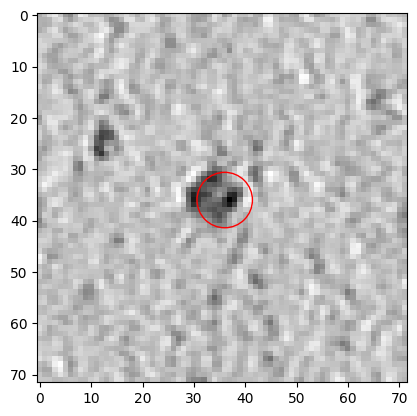

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utils.utils import load_coordinates_xyz, load_labels, load_tomogram, z_score_normalize
import matplotlib.patches as patches

tomo = z_score_normalize(load_tomogram('TS_73_6', 'denoised'))
coords = load_coordinates_xyz('TS_73_6', 'beta-galactosidase')
tomo_arr = np.array(z_score_normalize(tomo))
print(tomo_arr.std(), tomo_arr.mean())

coord = coords[4]
z, y, x = int(coord['z'] // 10), int(coord['y'] //10), int(coord['x'] // 10)
print(z, y, x)
plt.imshow(tomo[z, y-36:y+36, x-36:x+36], cmap='gray')\

ax = plt.gca()
circle = patches.Circle((36, 36), radius=9 * 0.6, edgecolor='red', facecolor='none')
ax.add_patch(circle)
plt.show()

1.0000004 -3.6894587e-08
37 357 313


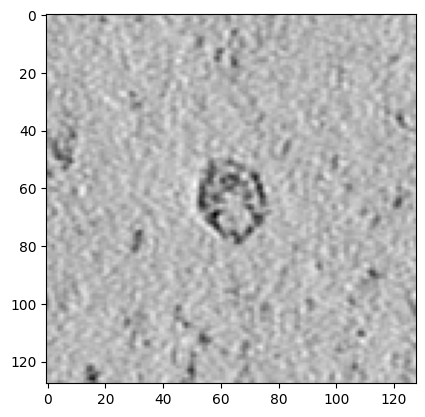

In [4]:
from utils.utils import load_coordinates_xyz, load_labels, load_tomogram
import numpy as np

exp = 'TS_5_4'
tomo = z_score_normalize(load_tomogram(exp))
tomo_arr = np.array((tomo))
print(tomo_arr.std(), tomo_arr.mean())
coords = load_coordinates_xyz(exp, 'virus-like-particle')

coord = coords[7]
z, y, x = int(coord['z'] // 10), int(coord['y'] // 10), int(coord['x'] // 10)
print(z, y, x)
plt.imshow(tomo[z, y-64:y+64, x-64:x+64], cmap='gray')
plt.show()

In [7]:
import torch
import torch.onnx
import onnx
from models.cryo_unet import CryoResUNet3D
from configs.cfg import cfg
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

fold = 6

cfg.device = 'cuda'
cfg.feature_maps = [24, 48, 72, 106]
cfg.use_scSE = True
weights = f'logs/checkpoints/CRYOET-420/swa_epoch_{99}_fold{fold}.pth'
checkpoint = torch.load(weights)
new_state_dict = {}
for k, v in checkpoint["model"].items():
    new_k = k.replace("module.", "")  # Remove the prefix
    new_k = new_k.replace("basic_", "basic_module.")  # Remove the prefix
    new_k = new_k.replace("_orig_mod.", "")  # Remove the prefix
    new_state_dict[new_k] = v

model = CryoResUNet3D(cfg).to(cfg.device)
model.load_state_dict(new_state_dict, strict=False)
model.eval()

# Dummy Input for ONNX Conversion
dummy_input = torch.randn(16, 1, 72, 72, 72, device=cfg.device)  # Adjust size accordingly

# Export to ONNX
onnx_file = f"logs/output/CRYOET420_fold{fold}.onnx"
torch.onnx.export(
    model, 
    dummy_input, 
    onnx_file,
    export_params=True,
    opset_version=15,
    do_constant_folding=True,
    input_names=["input"], 
    output_names=["output"],
    # Removed dynamic_axes
    dynamic_axes={"input": {0: "batch_size"}, 
                  "output": {0: "batch_size"}}
)

print(f"Exported PyTorch model to {onnx_file}")

# 5) (Optional) Validate the ONNX file
onnx_model = onnx.load(onnx_file)
onnx.checker.check_model(onnx_model)
print("ONNX model is valid!")


! /usr/src/tensorrt/bin/trtexec \
  --onnx=logs/output/CRYOET420_fold6.onnx \
  --saveEngine=logs/output/CRYOET420_fold6.plan \
  --fp16 \
  --minShapes=input:1x1x72x72x72 \
  --optShapes=input:16x1x72x72x72 \
  --maxShapes=input:16x1x72x72x72 \




/tmp/ipykernel_1347107/2883655673.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(weights)


Exported PyTorch model to logs/output/CRYOET420_fold6.onnx
ONNX model is valid!
&&&& RUNNING TensorRT.trtexec [TensorRT v100800] [b43] # /usr/src/tensorrt/bin/trtexec --onnx=logs/output/CRYOET420_fold6.onnx --saveEngine=logs/output/CRYOET420_fold6.plan --fp16 --minShapes=input:1x1x72x72x72 --optShapes=input:16x1x72x72x72 --maxShapes=input:16x1x72x72x72
[02/05/2025-08:26:22] [I] === Model Options ===
[02/05/2025-08:26:22] [I] Format: ONNX
[02/05/2025-08:26:22] [I] Model: logs/output/CRYOET420_fold6.onnx
[02/05/2025-08:26:22] [I] Output:
[02/05/2025-08:26:22] [I] === Build Options ===
[02/05/2025-08:26:22] [I] Memory Pools: workspace: default, dlaSRAM: default, dlaLocalDRAM: default, dlaGlobalDRAM: default, tacticSharedMem: default
[02/05/2025-08:26:22] [I] avgTiming: 8
[02/05/2025-08:26:22] [I] Precision: FP32+FP16
[02/05/2025-08:26:22] [I] LayerPrecisions: 
[02/05/2025-08:26:22] [I] Layer Device Types: 
[02/05/2025-08:26:22] [I] Calibration: 
[02/05/2025-08:26:22] [I] Refit: Disabled
[

In [1]:
import tensorrt as trt

TRT_LOGGER = trt.Logger(trt.Logger.WARNING)

def build_engine(onnx_file_path, engine_file_path):
    builder = trt.Builder(TRT_LOGGER)
    network = builder.create_network(1 << int(trt.NetworkDefinitionCreationFlag.EXPLICIT_BATCH))
    config = builder.create_builder_config()
    parser = trt.OnnxParser(network, TRT_LOGGER)

    with open(onnx_file_path, "rb") as model_file:
        if not parser.parse(model_file.read()):
            for error in range(parser.num_errors):
                print(f"ERROR: {parser.get_error(error)}")
            return None

    profile = builder.create_optimization_profile()
    profile.set_shape("input", (1,1,72,72,72), (16,1,72,72,72), (16,1,72,72,72))
    config.add_optimization_profile(profile)
    
    config.set_flag(trt.BuilderFlag.FP16)

    engine = builder.build_serialized_network(network, config)
    if engine is None:
        print("Failed to build the engine!")
        return None

    with open(engine_file_path, "wb") as f:
        f.write(engine)
    print(f"Successfully saved TensorRT engine to {engine_file_path}")

    return engine

# Example usage
onnx_model_path = "logs/output/G1CRYOET271_fold0.onnx"
trt_engine_path = "logs/output/G1CRYOET271_fold0.plan"
build_engine(onnx_model_path, trt_engine_path)


Successfully saved TensorRT engine to logs/output/G1CRYOET271_fold0.plan


In [3]:
a = (5,10,15)
b = (1, 1, 1)



TypeError: unsupported operand type(s) for -: 'tuple' and 'tuple'